# RQ4 — Correlation

In [1]:
import sys

sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from experiments._loader import load_all_results, success_only
from experiments._analysis import (
    setup_matplotlib,
    tex,
    IMG_COLS,
    ALL_CORRUPT_COLS,
)

setup_matplotlib()

df_all = load_all_results(include_baseline_fail=True)
df = success_only(df_all)

MODELS = [m for m in sorted(df.model.unique()) if (df.model == m).sum() >= 30]

MODEL_LABEL = {
    "qwen": "Qwen3-VL",
    "kimi": "Kimi-VL",
    "intern": "InternVL-3.5",
    "gemma": "Gemma3-4B",
    "deepseek": "Deepseek-VL2",
    "nemotron": "Nemotron3-ON",
}

SCENE_LABEL = {
    "single/solo": "SC-SI",
    "single/multi": "SC-MI",
    "multi": "MC",
    "udacity": "Driving",
}
SCENES = ["single/solo", "single/multi", "multi", "udacity"]


def mlabel(m):
    return MODEL_LABEL.get(m, tex(m))


print("Models:", [mlabel(m) for m in MODELS])

Models: ['InternVL-3.5', 'Kimi-VL', 'Nemotron3-ON', 'Qwen3-VL']


In [2]:
[f"{m} {(df.model == m).sum()}" for m in df.model.unique()]

['deepseek 24',
 'gemma 12',
 'intern 396',
 'kimi 330',
 'nemotron 492',
 'qwen 837']

## Attack Distributions

<>:86: SyntaxWarning: invalid escape sequence '\%'
<>:86: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_65561/3290884501.py:86: SyntaxWarning: invalid escape sequence '\%'
  ax_cb.set_ylabel("\% IoU reduction")


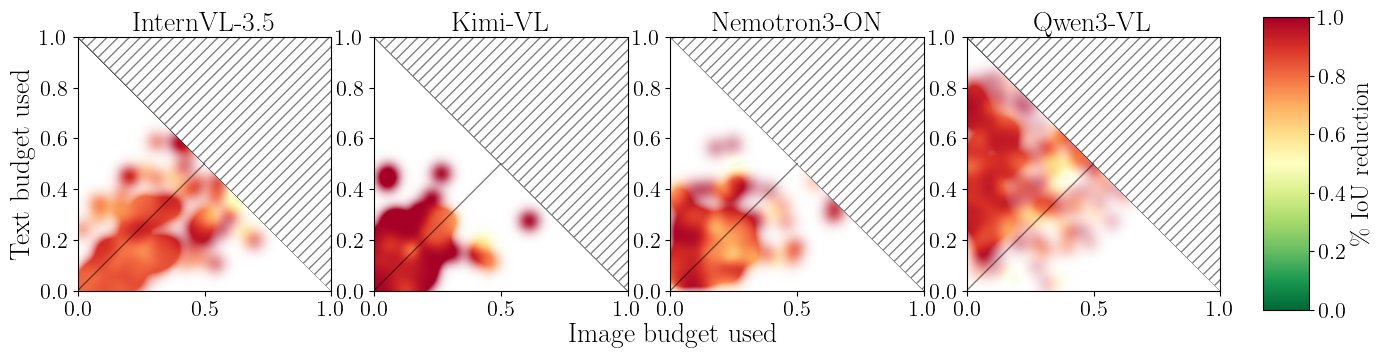

In [24]:
from matplotlib.patches import Polygon
sub_mm = df[(df["genome_mode"] == "multi") & df["model"].isin(MODELS)]
sub_mm = sub_mm.dropna(subset=["img_budget_used", "txt_budget_used"])

GS = 500
SIGMA = 0.03
xi = np.linspace(0, 1, GS)
yi = np.linspace(0, 1, GS)
gx, gy = np.meshgrid(xi, yi)

n = len(MODELS)
CELL = 3.8
CB_W = 0.18

fig, axes = plt.subplots(
    1,
    n + 1,
    figsize=(n * CELL + CELL * CB_W, CELL),
    gridspec_kw={"width_ratios": [1] * n + [CB_W]},
)
data_axes, ax_cb = axes[:n], axes[n]

for k, (ax, model) in enumerate(zip(data_axes, MODELS)):
    sub = sub_mm[sub_mm["model"] == model]
    px = sub["img_budget_used"].values
    py = sub["txt_budget_used"].values
    val = sub["iou_reduction"].values

    weighted_sum = np.zeros((GS, GS))
    weight_total = np.zeros((GS, GS))
    for xp, yp, v in zip(px, py, val):
        w = np.exp(-((gx - xp) ** 2 + (gy - yp) ** 2) / (2 * SIGMA**2))
        weighted_sum += w * v
        weight_total += w

    color = np.where(weight_total > 0, weighted_sum / weight_total, 0.0)
    pos_w = weight_total[weight_total > 0]
    if pos_w.size == 0:
        alpha = np.zeros_like(weight_total)
    else:
        alpha_scale = np.percentile(pos_w, 90)
        if alpha_scale <= 0:
            alpha = np.zeros_like(weight_total)
        else:
            alpha = np.clip(weight_total / alpha_scale, 0, 1)

    norm = plt.Normalize(vmin=0, vmax=1)
    rgba = plt.cm.RdYlGn_r(norm(color))
    rgba[..., 3] = alpha

    ax.imshow(rgba, origin="lower", extent=[0, 1, 0, 1], aspect="equal")

    invalid_region = Polygon(
        [(0, 1), (1, 1), (1, 0)],
        closed=True,
        facecolor="white",
        edgecolor="none",
        zorder=3,
        )
    ax.add_patch(invalid_region)

    # Add diagonal stripes over the masked region
    hatched_region = Polygon(
        [(0, 1), (1, 1), (1, 0)],
        closed=True,
        facecolor="none",
        edgecolor="gray",
        hatch="///",
        linewidth=0,
        zorder=4,
    )
    ax.add_patch(hatched_region)
    ax.plot([0, 0.5], [0, 0.5],color="black", alpha=0.5, linewidth=1, zorder=10)
    ax.plot([0, 1], [1, 0],color="black", linewidth=1)
    ax.set_aspect("equal")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_zorder(10)
    if k == 0:
        ax.set_ylabel("Text budget used", fontsize=20)
    ax.set_title(mlabel(model), fontsize=20, pad=4)
fig.supxlabel("Image budget used", fontsize=20)
sm = plt.cm.ScalarMappable(cmap="RdYlGn_r", norm=norm)
sm.set_array([])
plt.colorbar(sm, cax=ax_cb)
ax_cb.set_ylabel("\% IoU reduction")

plt.savefig("figures/rq4_budget_heatmap.pdf", dpi=150, bbox_inches="tight")
plt.show()

 ## Modality Sensitivity

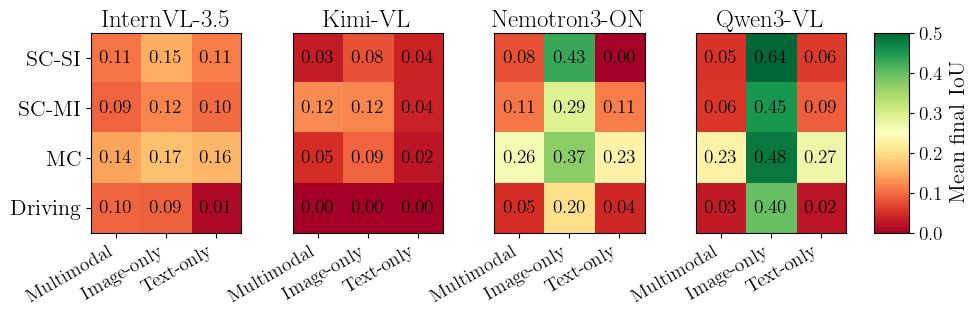

In [4]:
GMODES = ["multi", "image", "text"]
GMODE_LABEL = {"multi": "Multimodal", "image": "Image-only", "text": "Text-only"}
nr, nc = len(SCENES), len(GMODES)

n = len(MODELS)
CELL = 2.6
CB_W = 0.18

fig, axes = plt.subplots(
    1,
    n + 1,
    figsize=(n * CELL + CELL * CB_W, CELL),
    gridspec_kw={"width_ratios": [1] * n + [CB_W], "wspace": 0.02},
)
data_axes, ax_cb = axes[:n], axes[n]

for k, (ax, model) in enumerate(zip(data_axes, MODELS)):
    matrix = np.full((nr, nc), np.nan)
    for i, scene in enumerate(SCENES):
        for j, gmode in enumerate(GMODES):
            sub = df[(df.model == model) & (df.obj_category == scene) & (df.genome_mode == gmode)]
            if len(sub) >= 3:
                matrix[i, j] = sub["final_iou"].mean()

    im = ax.imshow(matrix, cmap="RdYlGn", vmin=0, vmax=0.5, aspect="equal")
    ax.set_aspect("equal")
    if k == 0:
        ax.set_yticks(range(nr))
        ax.set_yticklabels([SCENE_LABEL[s] for s in SCENES], fontsize=16)
    else:
        ax.set_yticks([])
    ax.set_xticks(range(nc))
    ax.set_xticklabels([GMODE_LABEL[g] for g in GMODES], rotation=30, ha="right", fontsize=14)
    ax.set_title(mlabel(model), fontsize=18, pad=4)
    for i in range(nr):
        for j in range(nc):
            if not np.isnan(matrix[i, j]):
                ax.text(
                    j,
                    i,
                    f"{matrix[i,j]:.2f}",
                    ha="center",
                    va="center",
                    fontsize=14,
                    color="k",
                    fontweight="bold",
                )

plt.colorbar(im, cax=ax_cb)
ax_cb.set_ylabel("Mean final IoU", fontsize=16)
ax_cb.tick_params(labelsize=14)

plt.savefig("figures/rq4_scene_modality_heatmap.pdf", dpi=150, bbox_inches="tight")
plt.show()

## Corruption Fingerprints of Successful Attacks

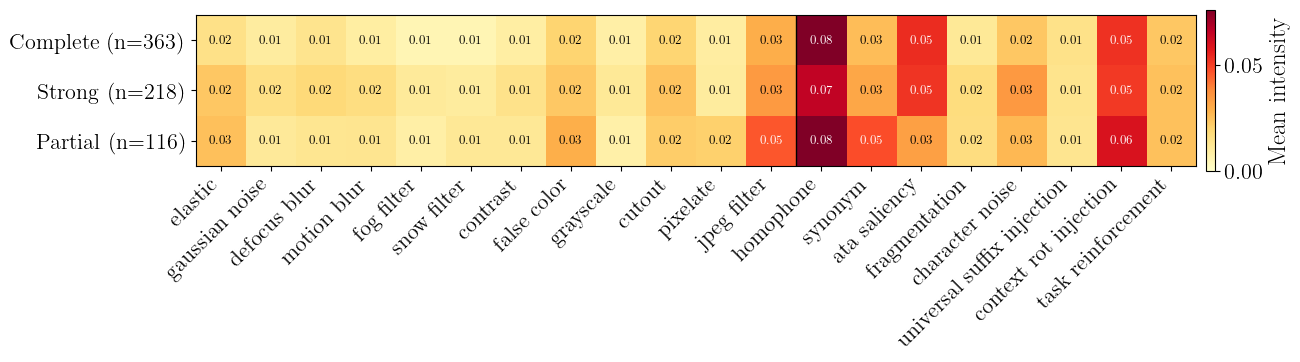

In [5]:
sub = df[df["genome_mode"] == "multi"].copy()
sub["outcome"] = pd.cut(
    sub["final_iou"], bins=[-0.001, 0.001, 0.25, 1.0], labels=["Complete", "Strong", "Partial"]
)

xlabels = [tex(c.removeprefix("img_").removeprefix("txt_")) for c in ALL_CORRUPT_COLS]
outcomes = ["Complete", "Strong", "Partial"]
nr, nc = len(outcomes), len(ALL_CORRUPT_COLS)

matrix = np.array(
    [[sub[sub["outcome"] == o][c].mean() for c in ALL_CORRUPT_COLS] for o in outcomes]
)
counts = {o: (sub["outcome"] == o).sum() for o in outcomes}

cell_px = 0.55  # size of one square cell in inches
fig, ax = plt.subplots(figsize=(nc * cell_px + 2.0, nr * cell_px + 1.5))
im = ax.imshow(matrix, cmap="YlOrRd", aspect="equal", vmin=0, vmax=matrix.max())
ax.set_xticks(range(nc))
ax.set_xticklabels(xlabels, rotation=45, ha="right")
ax.set_yticks(range(nr))
ax.set_yticklabels([f"{o}  (n={counts[o]})" for o in outcomes])
ax.axvline(len(IMG_COLS) - 0.5, color="black", lw=1)
for i in range(nr):
    for j in range(nc):
        v = matrix[i, j]
        ax.text(
            j,
            i,
            f"{v:.2f}",
            ha="center",
            va="center",
            fontsize=9,
            color="k" if v < matrix.max() * 0.6 else "w",
        )
cbar = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
cbar.set_label("Mean intensity")
plt.tight_layout(pad=0.3)
plt.savefig("figures/rq4_corruption_fingerprints.pdf", dpi=150, bbox_inches="tight")
plt.show()

## Success Attribution

InternVL-3.5: n=132, alpha=1000, R2=0.034
Kimi-VL: n=110, alpha=316.2, R2=0.110
Nemotron3-ON: n=164, alpha=177.8, R2=0.151
Qwen3-VL: n=279, alpha=1000, R2=0.051


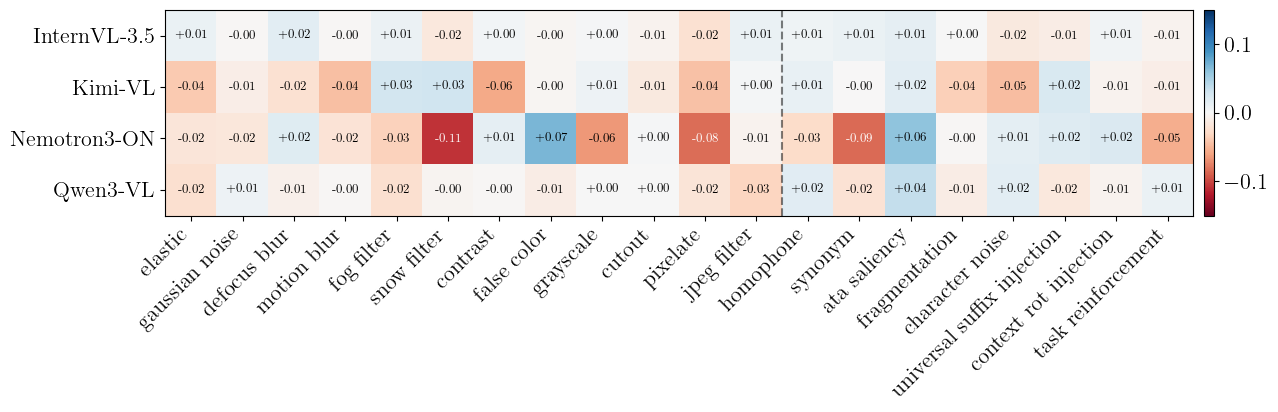

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

sub_mm = df[df["genome_mode"] == "multi"].copy()

xlabels = [
    tex(c.removeprefix("img_").removeprefix("txt_"))
    for c in ALL_CORRUPT_COLS
]

model_names = []
coef_rows = []

alphas = np.logspace(-3, 3, 25)

for model in MODELS:
    sub = sub_mm[sub_mm["model"] == model].copy()
    cols = ["iou_reduction"] + ALL_CORRUPT_COLS
    sub = sub[cols].dropna()

    if len(sub) < 10:
        continue

    X = sub[ALL_CORRUPT_COLS].to_numpy()
    y = sub["iou_reduction"].to_numpy()
    varying = np.std(X, axis=0) > 0

    coefs = np.zeros(len(ALL_CORRUPT_COLS))

    if varying.sum() > 0:
        X_var = X[:, varying]
        X_scaler = StandardScaler()
        y_scaler = StandardScaler()

        X_std = X_scaler.fit_transform(X_var)
        y_std = y_scaler.fit_transform(y.reshape(-1, 1)).ravel()

        model_ridge = RidgeCV(alphas=alphas)
        model_ridge.fit(X_std, y_std)

        coefs[varying] = model_ridge.coef_

        print(
            f"{mlabel(model)}: "
            f"n={len(sub)}, alpha={model_ridge.alpha_:.4g}, "
            f"R2={model_ridge.score(X_std, y_std):.3f}"
        )

    model_names.append(mlabel(model))
    coef_rows.append(coefs)

vals = np.asarray(coef_rows)
nr, nc = vals.shape

cell_px = 0.55
fig, ax = plt.subplots(
    figsize=(nc * cell_px + 2.0, nr * cell_px + 1.5)
)


im = ax.imshow(
    vals,
    cmap="RdBu",
    vmin=-0.15,
    vmax=0.15,
    aspect="equal",
)

ax.set_xticks(range(nc))
ax.set_xticklabels(
    xlabels,
    rotation=45,
    ha="right",
)

ax.set_yticks(range(nr))
ax.set_yticklabels(model_names)
ax.axvline(
    len(IMG_COLS) - 0.5,
    color="k",
    lw=1.5,
    ls="--",
    alpha=0.5,
)

for i in range(nr):
    for j in range(nc):
        v = vals[i, j]

        ax.text(
            j,
            i,
            f"{v:+.2f}",
            ha="center",
            va="center",
            fontsize=9,
            color="k" if abs(v) < 0.15 * 0.5 else "w",
        )

cbar = plt.colorbar(
    im,
    ax=ax,
    fraction=0.02,
    pad=0.01,
)

plt.tight_layout(pad=0.3)

plt.savefig(
    "figures/rq4_corruption_attribution.pdf",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

### Recoverability

In [7]:
import json
from pathlib import Path
from tqdm.notebook import tqdm
from PIL import Image

from experiments._analysis import (
    RECOVERY_COLORS,
    RECOVERY_ORDER,
    classify_termination_series,
    evaluate_recovered_predictions,
    recover_json_bboxes_with_ollama,
    resolve_original_image_path,
)
from experiments.config.experiment import BASELINE_IOU_MIN
from experiments.config.paths import OLLAMA_HOST

df_term = classify_termination_series(df_all)
malformed = df_term[df_term["termination_type"] == "JSON malformed"].copy()
print(f"Malformed JSON rows: {len(malformed)}")

records = []
for i, (_, row) in tqdm(enumerate(malformed.iterrows(), start=1)):
    artifact = json.loads(Path(row["_result_json_path"]).read_text())
    vlm_output = artifact.get("vlm_output", {})
    raw_response = str(vlm_output.get("raw_response", "") or "")
    prompt_objects = vlm_output.get("prompt_objects", [])
    gt_boxes = artifact.get("ground_truth_bboxes", [])

    recovered_iou = np.nan
    recovered_count = 0
    recoverability = "Unrecoverable"

    if raw_response and gt_boxes:
        recovered = recover_json_bboxes_with_ollama(
            raw_response,
            prompt_objects,
            model="granite4.1:8b",
            host=OLLAMA_HOST,
            timeout=180,
        )
        if recovered:
            with Image.open(resolve_original_image_path(str(row["_orig_img_folder"]))) as image:
                original_size = image.size
            recovered_iou = evaluate_recovered_predictions(
                recovered,
                gt_boxes,
                original_size,
                model_name=str(row["model"]),
            )
            recovered_count = len(recovered)
            recoverability = (
                "Recovered and would pass"
                if recovered_iou >= BASELINE_IOU_MIN
                else "Recovered but still fail"
            )

    records.append(
        {
            "model": row["model"],
            "folder_id": row["folder_id"],
            "recoverability": recoverability,
            "recovered_iou": recovered_iou,
            "recovered_count": recovered_count,
        }
    )

recovery_df = pd.DataFrame(records)

Malformed JSON rows: 906


0it [00:00, ?it/s]

<>:21: SyntaxWarning: invalid escape sequence '\#'
<>:21: SyntaxWarning: invalid escape sequence '\#'
/tmp/ipykernel_3590042/668836819.py:21: SyntaxWarning: invalid escape sequence '\#'
  ax.set_ylabel("\# Malformed JSON")


recoverability,Unrecoverable,Recovered but still fail,Recovered and would pass
Deepseek-VL2,99,1,0
Gemma3-4B,12,0,0
InternVL-3.5,38,3,9
Kimi-VL,341,59,177
Nemotron3-ON,21,2,4
Qwen3-VL,100,30,10


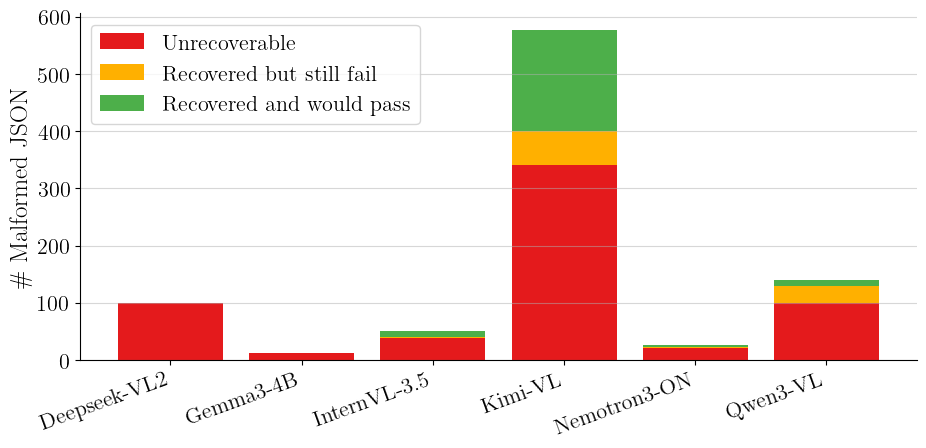

In [8]:
summary = recovery_df.groupby(["model", "recoverability"]).size().unstack(fill_value=0)
for label in RECOVERY_ORDER:
    if label not in summary.columns:
        summary[label] = 0
summary = summary[RECOVERY_ORDER].sort_index()

summary_named = summary.copy()
summary_named.index = [mlabel(model) for model in summary_named.index]
display(summary_named)

fig, ax = plt.subplots(figsize=(max(6, 1.8 * len(summary_named)), 4.5))
bottom = np.zeros(len(summary_named), dtype=float)
x = np.arange(len(summary_named))
ax.grid(axis="y", alpha=0.5)
for label in RECOVERY_ORDER:
    values = summary_named[label].to_numpy(dtype=float)
    ax.bar(x, values, bottom=bottom, color=RECOVERY_COLORS[label], label=label)
    bottom += values
ax.set_xticks(x)
ax.set_xticklabels(summary_named.index, rotation=20, ha="right")
ax.set_ylabel("\# Malformed JSON")
ax.legend(loc="best")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.savefig("figures/recovery.pdf", dpi=200, bbox_inches="tight")

### BBox Size Correlation

In [ ]:
import json
from pathlib import Path

from experiments._analysis import TERMINATION_COLORS, TERMINATION_ORDER, classify_termination_series
from experiments._loader import RESULTS_ROOT

BBOX_FEATURES = [
    "bbox_count",
    "bbox_area_pct_mean",
    "bbox_area_pct_median",
    "bbox_area_pct_max",
    "bbox_area_pct_min",
    "small_bbox_frac_side05",
]
BBOX_PRIMARY = "bbox_area_pct_median"
BBOX_SECONDARY = "small_bbox_frac_side05"
BBOX_MODELS = sorted(df_all["model"].unique())


def _original_json_path(folder_value):
    folder = Path(str(folder_value))
    if not folder.is_absolute():
        folder = RESULTS_ROOT / folder
    return folder / "original.json"


def _bbox_feature_row(folder_value):
    path = _original_json_path(folder_value)
    payload = json.loads(path.read_text())
    width, height = payload["original_dims"]
    boxes = list((payload.get("ground_truth") or {}).values())
    area_pcts = []
    small_flags = []
    for box in boxes:
        bw = max(0.0, float(box["xmax"]) - float(box["xmin"]))
        bh = max(0.0, float(box["ymax"]) - float(box["ymin"]))
        wf = bw / float(width)
        hf = bh / float(height)
        area_pcts.append((bw * bh) / float(width * height))
        small_flags.append(float((wf < 0.05) and (hf < 0.05)))
    return {
        "_orig_img_folder": str(folder_value),
        "bbox_count": int(len(area_pcts)),
        "bbox_area_pct_mean": float(np.mean(area_pcts)),
        "bbox_area_pct_median": float(np.median(area_pcts)),
        "bbox_area_pct_max": float(np.max(area_pcts)),
        "bbox_area_pct_min": float(np.min(area_pcts)),
        "small_bbox_frac_side05": float(np.mean(small_flags)),
    }


bbox_meta = pd.DataFrame(
    [_bbox_feature_row(folder) for folder in sorted(df_all["_orig_img_folder"].dropna().unique())]
)
df_bbox = classify_termination_series(df_all.merge(bbox_meta, on="_orig_img_folder", how="left"))
df_bbox["is_success"] = df_bbox["status"].eq("success").astype(int)

quartile_codes = pd.qcut(df_bbox[BBOX_PRIMARY], 4, labels=False, duplicates="drop")
quartile_count = int(quartile_codes.max() + 1)
quartile_labels = [f"Q{i + 1}" for i in range(quartile_count)]
df_bbox["bbox_area_pct_median_q"] = pd.Categorical(
    [quartile_labels[int(i)] if pd.notna(i) else np.nan for i in quartile_codes],
    categories=quartile_labels,
    ordered=True,
)

secondary_codes = pd.qcut(df_bbox[BBOX_SECONDARY].rank(method="first"), 4, labels=False, duplicates="drop")
secondary_count = int(secondary_codes.max() + 1)
secondary_labels = [f"Q{i + 1}" for i in range(secondary_count)]
df_bbox["small_bbox_frac_side05_q"] = pd.Categorical(
    [secondary_labels[int(i)] if pd.notna(i) else np.nan for i in secondary_codes],
    categories=secondary_labels,
    ordered=True,
)

missing_bbox = df_bbox[df_bbox[BBOX_FEATURES].isna().any(axis=1)][
    ["model", "folder_id", "filename", "_orig_img_folder"]
]
print(f"Rows with matched bbox metadata: {len(df_bbox) - len(missing_bbox)} / {len(df_bbox)}")
if len(missing_bbox):
    display(missing_bbox.drop_duplicates().head(20))

assert (df_bbox["bbox_count"] >= 1).all()
assert ((df_bbox["bbox_area_pct_min"] > 0) & (df_bbox["bbox_area_pct_max"] <= 1)).all()
assert ((df_bbox["small_bbox_frac_side05"] >= 0) & (df_bbox["small_bbox_frac_side05"] <= 1)).all()

term_counts = pd.crosstab(df_bbox["model"], df_bbox["termination_type"])
for label in TERMINATION_ORDER:
    if label not in term_counts.columns:
        term_counts[label] = 0
term_counts = term_counts[TERMINATION_ORDER].sort_index()
success_check = term_counts.sum(axis=1).rename("termination_total").to_frame()
success_check["row_total"] = df_bbox.groupby("model").size()
assert (success_check["termination_total"] == success_check["row_total"]).all()

model_summary = (
    df_bbox.groupby("model")
    .agg(
        testcase_count=("model", "size"),
        success_rate=("is_success", "mean"),
        mean_bbox_count=("bbox_count", "mean"),
        mean_bbox_area_pct_median=("bbox_area_pct_median", "mean"),
        mean_small_bbox_frac_side05=("small_bbox_frac_side05", "mean"),
        malformed_json_rate=("termination_type", lambda s: float((s == "JSON malformed").mean())),
    )
    .sort_index()
)
model_summary.index = [mlabel(model) for model in model_summary.index]

In [ ]:
success_by_q = (
    df_bbox.groupby(["bbox_area_pct_median_q", "model"])["is_success"]
    .mean()
    .unstack("model")
    .reindex(index=quartile_labels, columns=BBOX_MODELS)
)
n_models = len(BBOX_MODELS)
fig, axes = plt.subplots(1, n_models, figsize=(max(10, 3.1 * n_models), 4.6), sharey=True)
if n_models == 1:
    axes = [axes]
for ax, model in zip(axes, BBOX_MODELS):
    sub = df_bbox[df_bbox["model"] == model]
    counts = pd.crosstab(sub["bbox_area_pct_median_q"], sub["termination_type"]).reindex(quartile_labels)
    for label in TERMINATION_ORDER:
        if label not in counts.columns:
            counts[label] = 0
    counts = counts[TERMINATION_ORDER]
    props = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0)
    bottom = np.zeros(len(quartile_labels), dtype=float)
    for label in TERMINATION_ORDER:
        values = props[label].fillna(0).to_numpy(dtype=float)
        ax.bar(quartile_labels, values, bottom=bottom, color=TERMINATION_COLORS[label], label=label)
        bottom += values
    ax.set_title(mlabel(model))
    ax.set_xlabel(tex(BBOX_PRIMARY))
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
axes[0].set_ylabel("Termination share")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncols=3, bbox_to_anchor=(0.5, 1.14))
fig.tight_layout()
fig.savefig("figures/rq4_bbox_termination_mix.pdf", dpi=200, bbox_inches="tight")
plt.show()
